In [1]:
import selfTracking

In [2]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stat
import matplotlib.pyplot as plt
import os

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


I have already recorded some data about myself. Here I intend to utilise this package in order to answer such questions as:
- at which hours am I most productive?
- at which hours do I usually rest?
- how often should I take breaks?

## Gathering the data

First, one needs to load the raw data from the analyzer. In folder "./data/", multiple logs from many days are saved:

In [3]:
os.listdir("./data/")

['2022-10-1.txt',
 '2022-10-10.txt',
 '2022-10-11.txt',
 '2022-10-12.txt',
 '2022-10-13.txt',
 '2022-10-18.txt',
 '2022-10-19.txt',
 '2022-10-2.txt',
 '2022-10-20.txt',
 '2022-10-21.txt',
 '2022-10-22.txt',
 '2022-10-23.txt',
 '2022-10-24.txt',
 '2022-10-25.txt',
 '2022-10-26.txt',
 '2022-10-27.txt',
 '2022-10-28.txt',
 '2022-10-29.txt',
 '2022-10-3.txt',
 '2022-10-30.txt',
 '2022-10-31.txt',
 '2022-10-4.txt',
 '2022-10-5.txt',
 '2022-10-6.txt',
 '2022-10-7.txt',
 '2022-10-8.txt',
 '2022-10-9.txt',
 '2022-11-1.txt',
 '2022-11-10.txt',
 '2022-11-11.txt',
 '2022-11-12.txt',
 '2022-11-13.txt',
 '2022-11-14.txt',
 '2022-11-15.txt',
 '2022-11-16.txt',
 '2022-11-17.txt',
 '2022-11-18.txt',
 '2022-11-2.txt',
 '2022-11-20.txt',
 '2022-11-21.txt',
 '2022-11-22.txt',
 '2022-11-23.txt',
 '2022-11-24.txt',
 '2022-11-27.txt',
 '2022-11-28.txt',
 '2022-11-29.txt',
 '2022-11-3.txt',
 '2022-11-30.txt',
 '2022-11-4.txt',
 '2022-11-5.txt',
 '2022-11-6.txt',
 '2022-11-7.txt',
 '2022-11-8.txt',
 '2022-11-

The analyzer will read all said logs and concatenate them into a single dataframe:

In [3]:
analyzer = selfTracking.Analyzer(data_directory="./data/")
analyzer.load_raw_data()
analyzer.raw_data.head()

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed
0,0,2022,9,30,17,0,9,4,1.664550e+09,101182.081916,True,Licencjat Kognitywistyka - Online LaTeX Editor...,the Es [bckspc] xcitatory PostSynaptic Potenti...,tthheespacespaceright shiftEright shiftessback...
1,1,2022,10,1,21,6,31,5,1.664651e+09,46.196441,True,Untitled - Jupyter Notebook - Google Chrome,ctrltime.sleep(1,ctrlentertime.sleepright shift(1
2,2,2022,10,1,21,7,17,5,1.664651e+09,64.092524,True,Analiza - Jupyter Notebook - Google Chrome,t,right ctrlt
3,3,2022,10,1,21,8,21,5,1.664651e+09,6.712993,True,Nowa karta - Google Chrome,search for a value in object python,searchspaceforspaceaspacevaluespaceinspaceobje...
4,4,2022,10,1,21,8,28,5,1.664651e+09,7.579864,True,search for a value in object python - Szukaj w...,,


at this point, however, no block contains any flags (the 'flag' column does not yet exist). However, I have already previously set up the flag files and so the analyzer can set up these flags rather quickly:

In [4]:
analyzer.update_flag_file()
analyzer.assign_flags()
analyzer.raw_data[analyzer.raw_data.flag != ""].head()

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed,flag
337,131,2022,10,10,10,19,7,0,1.665390e+09,5.115039,True,Moistcr1tikal Watches - That Zone Between Area...,,,rest
636,430,2022,10,10,14,1,14,0,1.665403e+09,2.577624,True,Facebook - Google Chrome,,,rest
637,431,2022,10,10,14,1,17,0,1.665403e+09,600.035335,True,(7) Facebook - Google Chrome,hahah XD sorry nie amusiałem wiesza tak szczer...,hahahspaceright shiftXDspaceentersorryspaceent...,rest
638,432,2022,10,10,14,11,17,0,1.665404e+09,21.067164,False,(7) Facebook - Google Chrome,,,rest
639,433,2022,10,10,14,11,38,0,1.665404e+09,11.459162,True,(7) Facebook - Google Chrome,,,rest


As can be seen, some block have already been assigned to their respective flags.

Now, to make this into a time-series data with interesting statistics, let's first define the statistics that interes us:

In [5]:
def resting(row):
    return 1 if row.flag == 'rest' or row.active == False else 0

def words_per_second(row):
    return (len(row.textWritten.split(" ")) - 1) / row.secSpent if row.flag != 'rest' else 0


def letters_per_second(row):
    return (len(row.textWritten)) / row.secSpent if row.flag != 'rest' else 0

def is_block(row):
    return 1 if row.flag else 1

all_statistics = [resting, words_per_second, letters_per_second, is_block]

and now generate the time series data with said statistics:

In [6]:
data = analyzer.make_time_series( all_statistics )
data.head()

,index,resting,words_per_second,letters_per_second,is_block
1663800519,0.0,0.0,0.0,0.0,0.0
1663800579,0.0,0.0,0.0,0.0,0.0
1663800639,0.0,0.0,0.0,0.0,0.0
1663800699,0.0,0.0,0.0,0.0,0.0
1663800759,0.0,0.0,0.0,0.0,0.0


## Average productivity vs hour

In order to find out at which hours I am most productive, let's plot the quantity of my work versus the hour.

first need to get a column that represents time, but can also be interpreted by pandas

In [7]:
def get_time(row):
    sec = row.name
    time = dt.datetime.fromtimestamp( sec ).time()
    return time.hour*100 + time.minute*100/60

In [8]:
data["hour"] = data.apply( get_time  , axis = 1)

now to get a data of 'mean' for each day

In [9]:
by_hour = data.groupby( "hour" ).mean()

In [10]:
by_hour

,index,resting,words_per_second,letters_per_second,is_block
hour,,,,,
0.000000,8006.798988,0.277778,0.001367,0.008675,0.511111
1.666667,8007.003029,0.276996,0.002675,0.017271,0.511111
3.333333,8007.074155,0.288889,0.002438,0.016910,0.511111
5.000000,8007.184078,0.274101,0.000344,0.001825,0.511111
6.666667,8007.306993,0.266667,0.001697,0.009429,0.511111
...,...,...,...,...,...
2391.666667,8006.084308,0.288889,0.002363,0.017559,0.511111
2393.333333,8006.138272,0.288889,0.001290,0.009593,0.511111
2395.000000,8006.260467,0.284181,0.000852,0.006140,0.511111


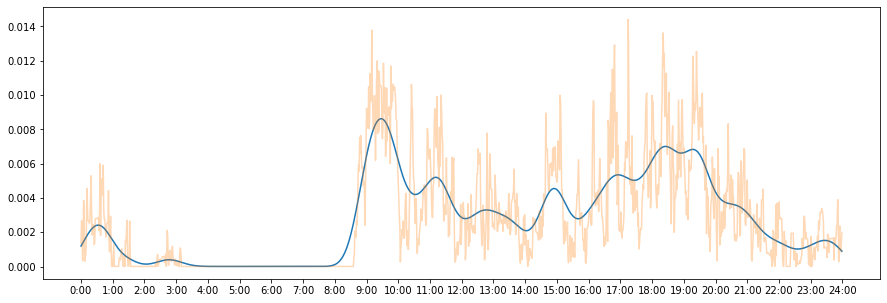

In [38]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1,0,2)*0.1 for i in range(-60,60)]
#smoothed_lps = np.convolve( by_hour.letters_per_second*10 , kernel , "same" )
smoothed_wpd = np.convolve( by_hour.words_per_second , kernel , "same" )

#ax.plot( by_hour.index , smoothed_lps )
ax.plot( by_hour.index , smoothed_wpd )
#ax.plot( by_hour.index ,  by_hour.letters_per_second*1 )
ax.plot( by_hour.index , by_hour.words_per_second , alpha = 0.3 )
fig.set_size_inches(15,5)

ax.set_xticks( [ i*100 for i in range(25) ] );
ax.set_xticklabels( [ f"{i}:00" for i in range(25) ] );


The high activity between hours 8:45-12:00 is almost certainly only due to taking notes during lectures. Aside from that, it appears I was most productive between 14 and 20 (with a lunch break at around 16:00). The results are far from what I have expected, as I have always considered myself to be most productive at night (although lack of work during the night is arbitrarily enforced by the presence of lectures at 8:30AM).

## Average "is resting" vs hour

In other words: during which time of the dat do I most often rest? Unfortunately, I either assume that I'm not resting while not using the computer or assume I am resting. However, considering I mostly work on my computer I will assume resting.

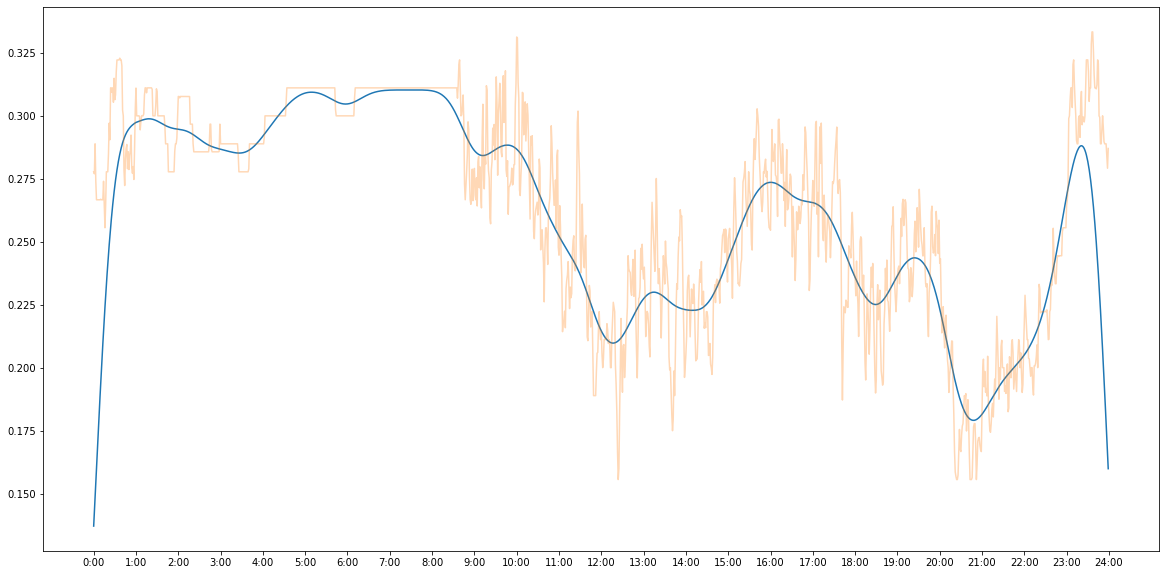

In [12]:
fig, ax = plt.subplots()


kernel = [ stat.norm.pdf(i*0.1,0,2)*0.1 for i in range(-60,60)]
smoothed_resting = np.convolve( by_hour.resting , kernel , "same" )

ax.plot( by_hour.index , smoothed_resting)
ax.plot( by_hour.index , by_hour.resting , alpha = 0.3 )
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] );
ax.set_xticklabels( [ f"{i}:00" for i in range(25) ] );


## Productivity vs time from last break plot

In [13]:
data.loc[:,"last_rest"] = 1 - data.loc[:,"resting"]*data.loc[:,"is_block"]

In [14]:
last_idx = 1666125515
for idx,row in data.iterrows():
    if row.resting != 1 and row.is_block:
        row.loc["last_rest"] = data.loc[last_idx,"last_rest"] + (idx - last_idx)/60
    last_idx = idx

In [15]:
data.head()

,index,resting,words_per_second,letters_per_second,is_block,hour,last_rest
1663800519,0.0,0.0,0.0,0.0,0.0,80.000000,1.0
1663800579,0.0,0.0,0.0,0.0,0.0,81.666667,1.0
1663800639,0.0,0.0,0.0,0.0,0.0,83.333333,1.0
1663800699,0.0,0.0,0.0,0.0,0.0,85.000000,1.0
1663800759,0.0,0.0,0.0,0.0,0.0,86.666667,1.0


In [30]:
rest_data = data[(data.last_rest < 60*5) & (data.words_per_second > 0)].groupby("last_rest").mean()

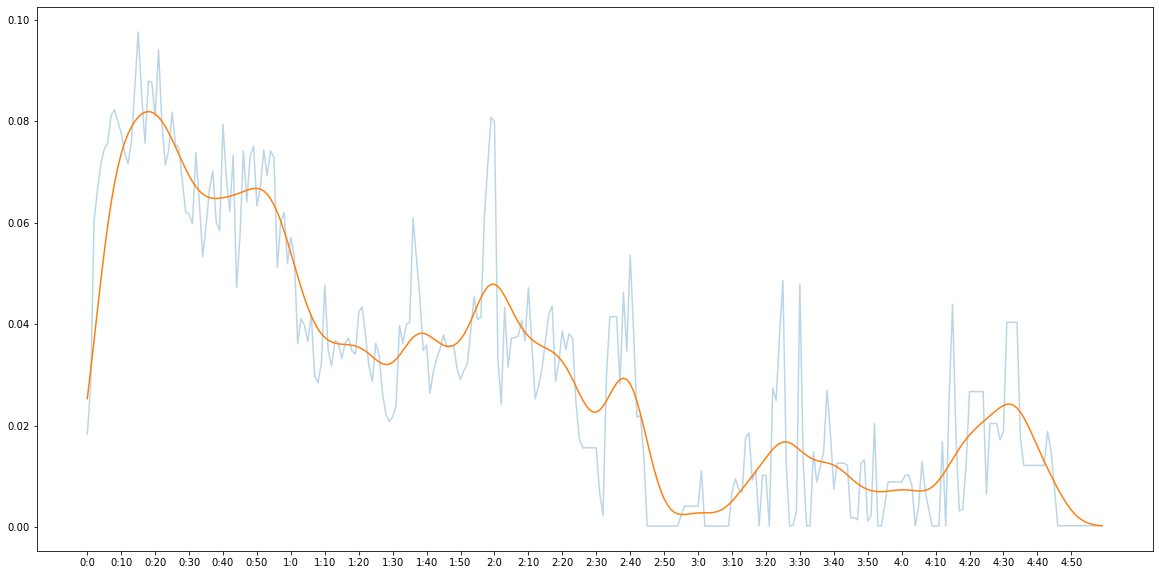

In [33]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1,0,0.5)*0.1 for i in range(-30,30)]
smoothed_words = np.convolve( rest_data.words_per_second , kernel , "same" )

fig.set_size_inches(20,10)
ax.plot( rest_data.index , rest_data.words_per_second, alpha = 0.3)
ax.plot( rest_data.index , smoothed_words )

ax.set_xticks( [ i*10 for i in range(6*5) ] );
ax.set_xticklabels( [ f"{round(i/6 - 0.49)}:{10*i%60}" for i in range(6*5) ] );


I appear to be about 3 times more productive within the first 30 minutes of my work than after 60 minutes of work. I should probably consider taking breaks more often.